In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA


In [2]:
# Load dataset
df = pd.read_csv("customer_churn_telecom_services.csv")

In [3]:
# Handle missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [4]:
# Convert categorical target variable to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

<ipython-input-5-611a5a76b0a1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Churn'], palette='coolwarm')


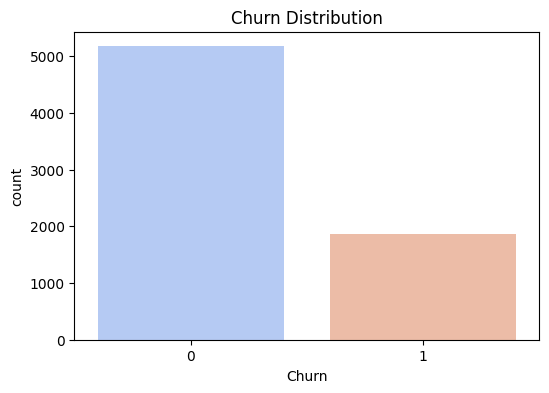

In [5]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.countplot(x=df['Churn'], palette='coolwarm')
plt.title("Churn Distribution")
plt.show()

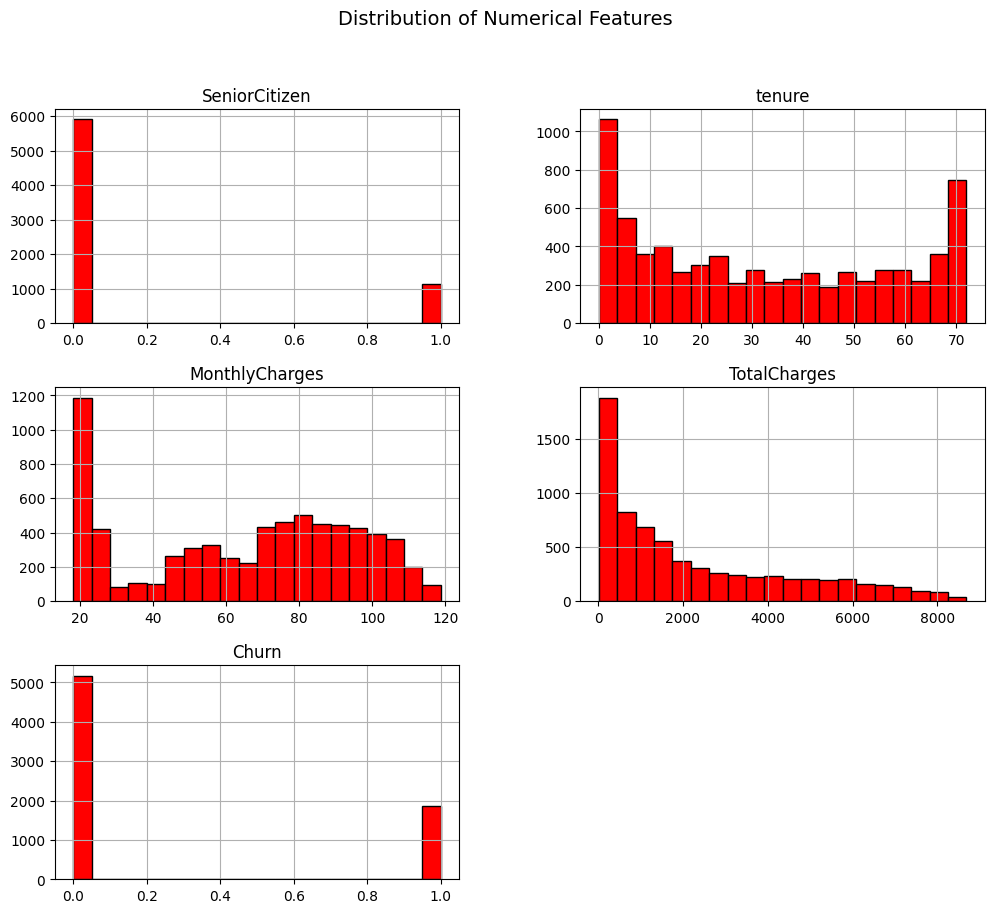

In [6]:
# Distribution of numerical features
df.hist(figsize=(12, 10), bins=20, color='red', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

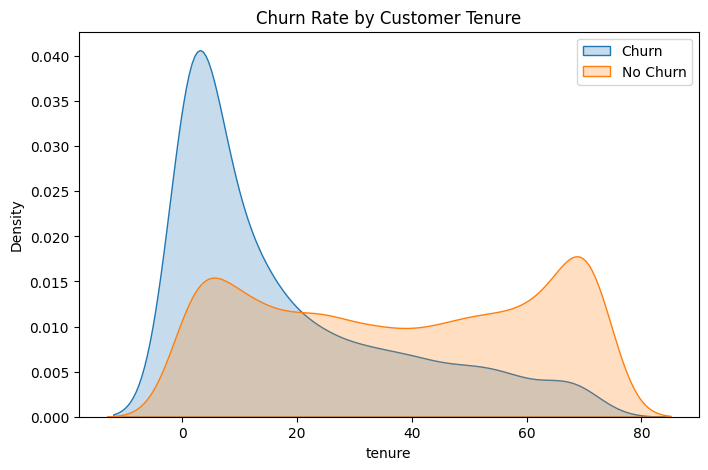

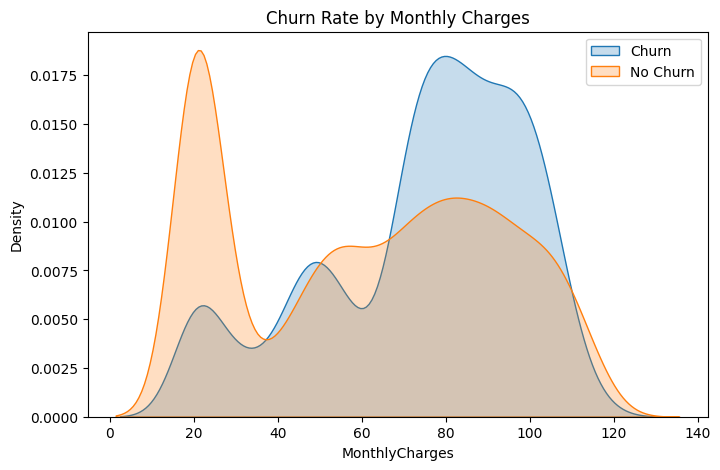

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


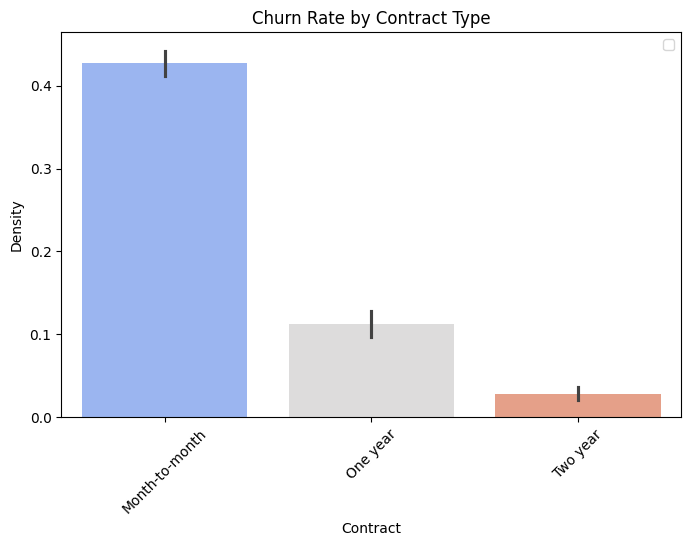

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


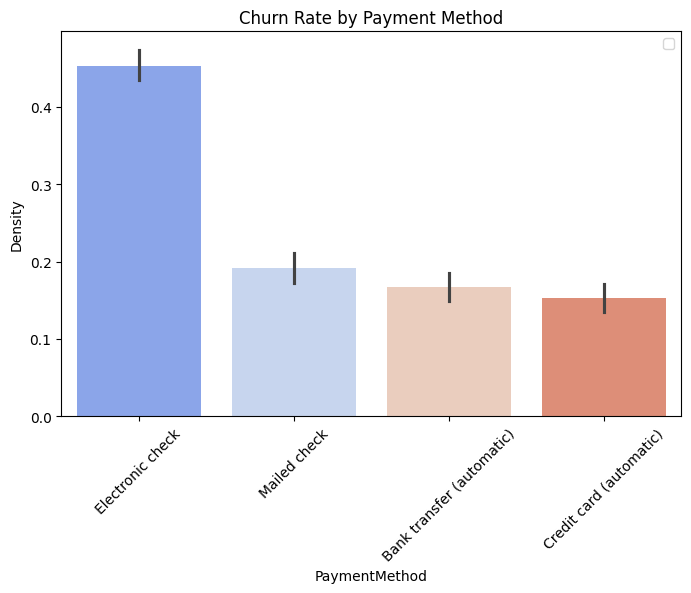

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


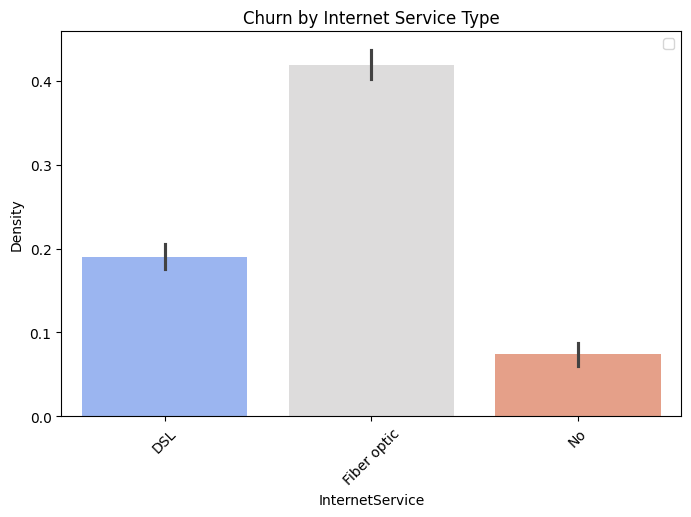

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


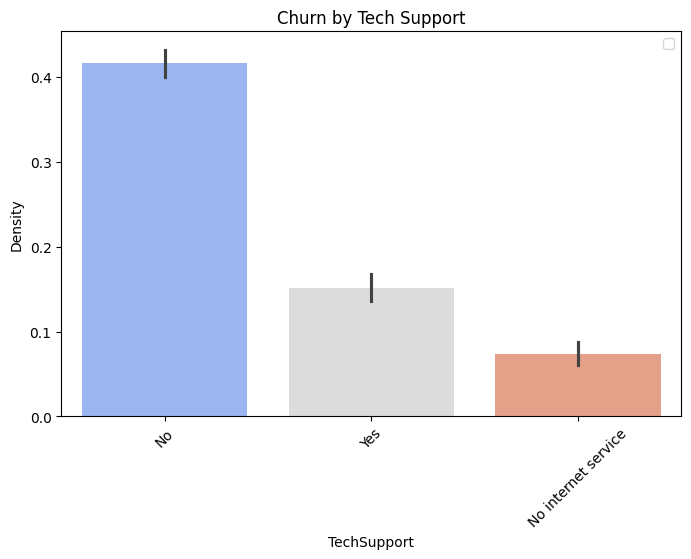

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


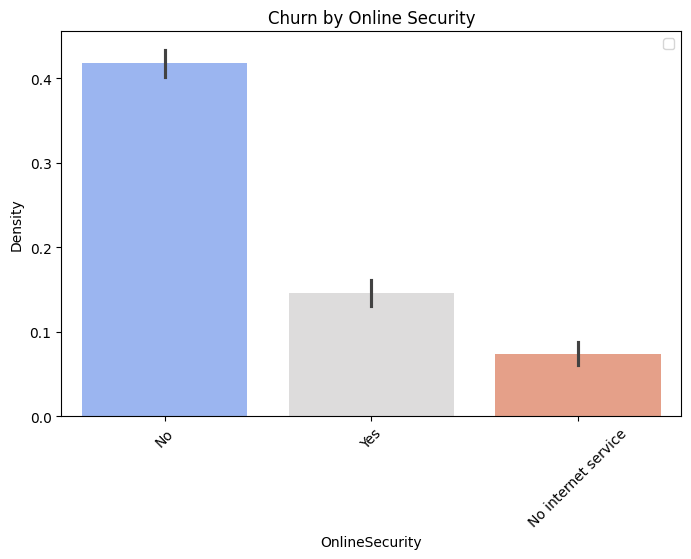

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


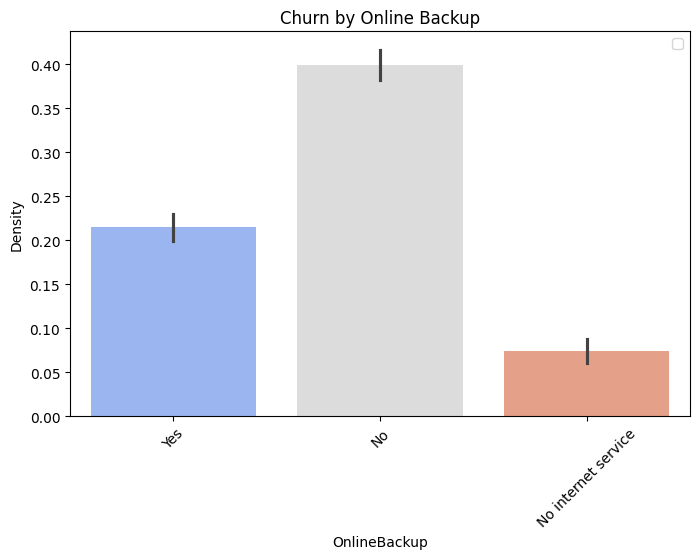

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


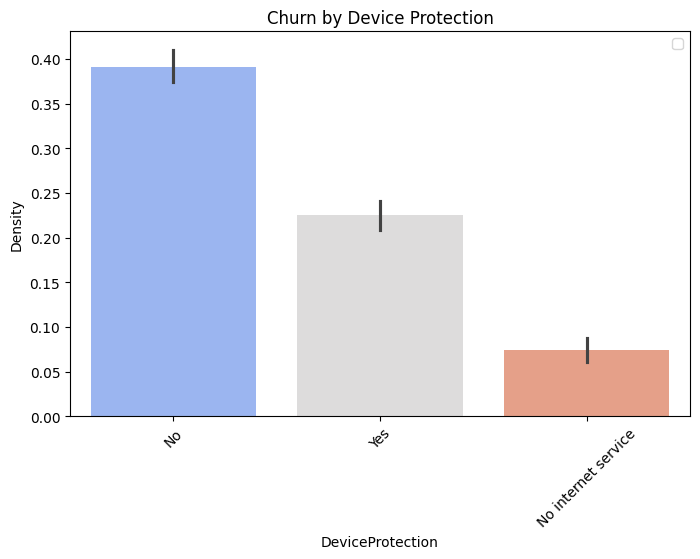

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


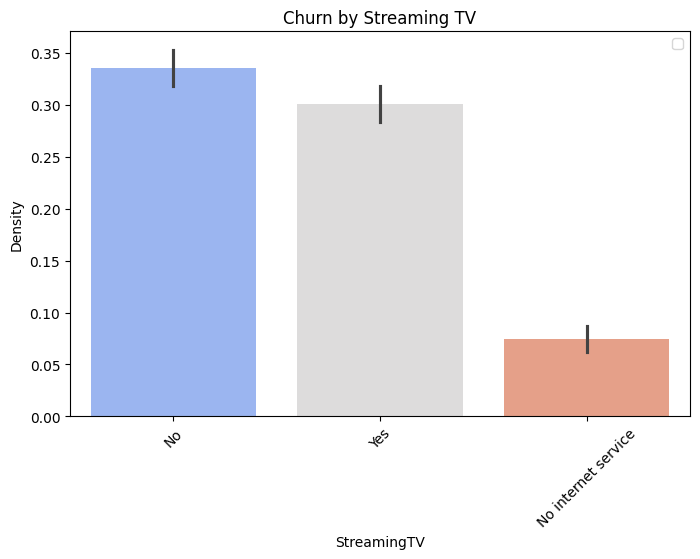

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


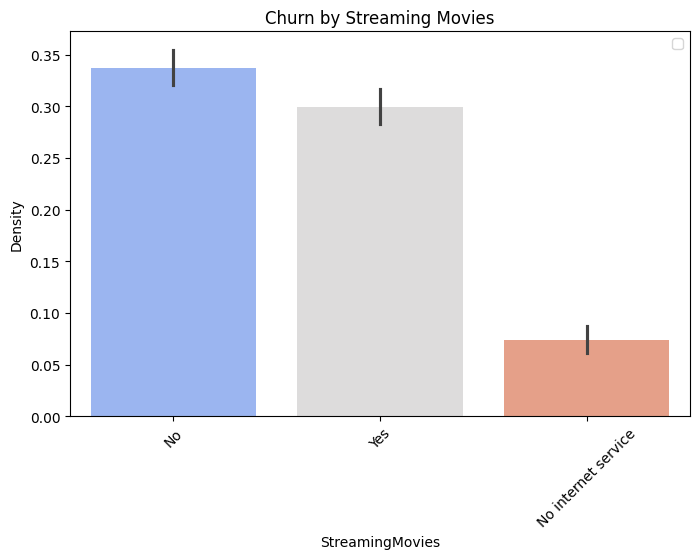

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


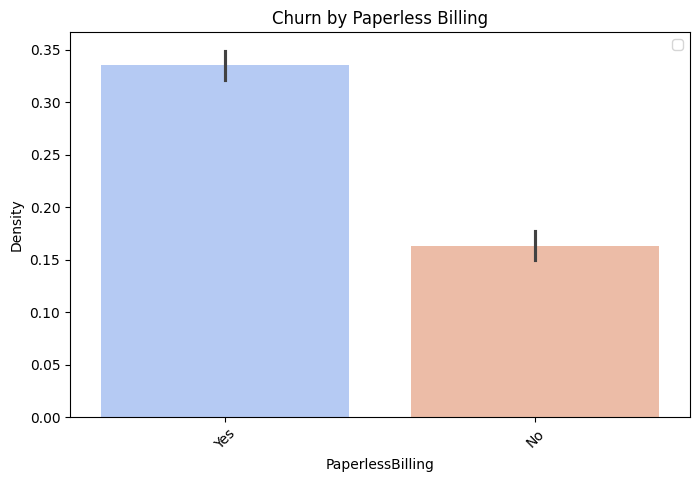

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


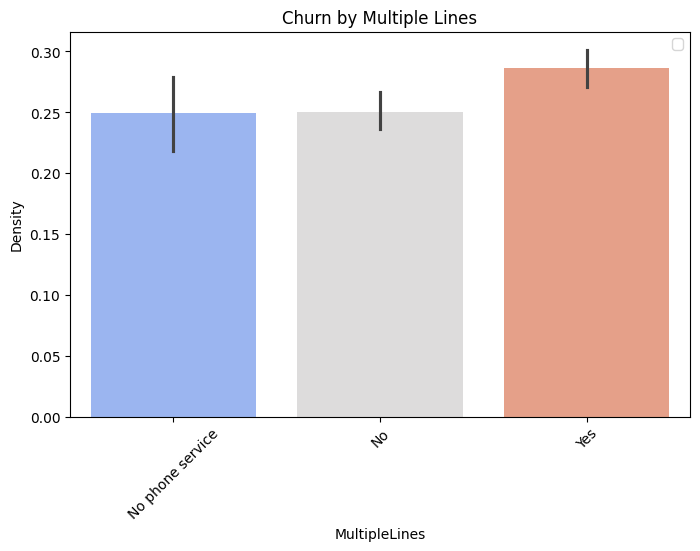

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


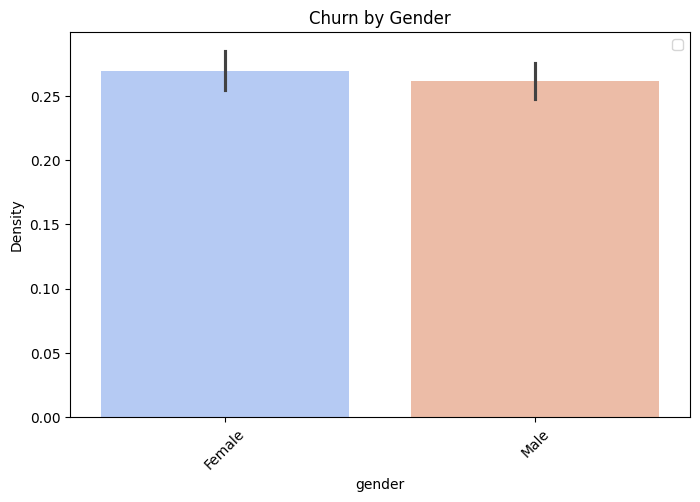

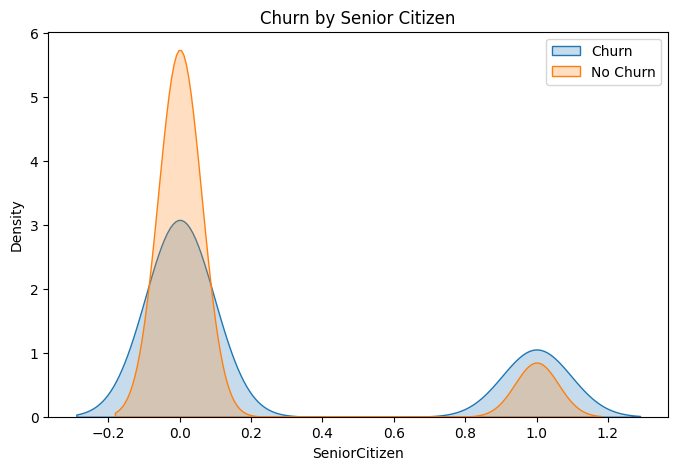

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


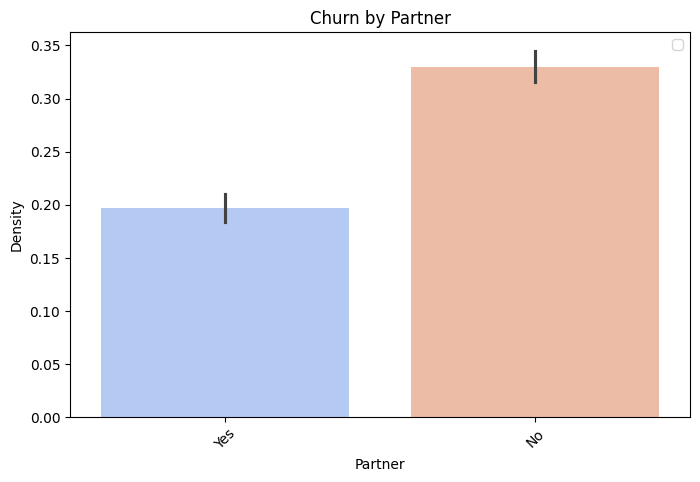

<ipython-input-7-2ce9615b77a3>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
<ipython-input-7-2ce9615b77a3>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


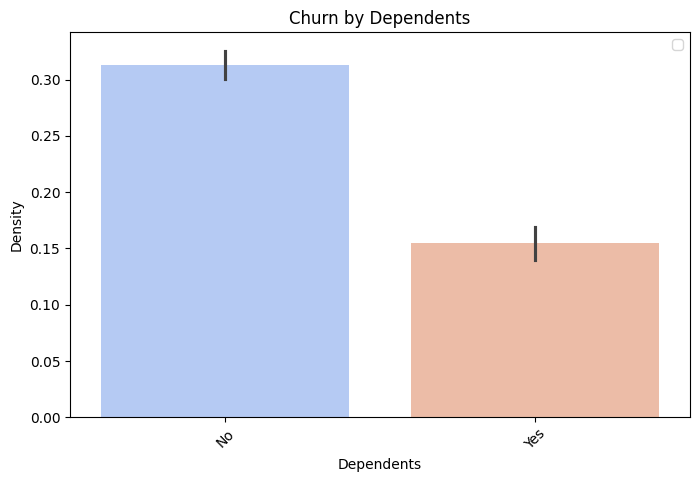

In [7]:
# Define visualizations
visualizations = [
    ("tenure", "Churn", "Churn Rate by Customer Tenure"),
    ("MonthlyCharges", "Churn", "Churn Rate by Monthly Charges"),
    ("Contract", "Churn", "Churn Rate by Contract Type"),
    ("PaymentMethod", "Churn", "Churn Rate by Payment Method"),
    ("InternetService", "Churn", "Churn by Internet Service Type"),
    ("TechSupport", "Churn", "Churn by Tech Support"),
    ("OnlineSecurity", "Churn", "Churn by Online Security"),
    ("OnlineBackup", "Churn", "Churn by Online Backup"),
    ("DeviceProtection", "Churn", "Churn by Device Protection"),
    ("StreamingTV", "Churn", "Churn by Streaming TV"),
    ("StreamingMovies", "Churn", "Churn by Streaming Movies"),
    ("PaperlessBilling", "Churn", "Churn by Paperless Billing"),
    ("MultipleLines", "Churn", "Churn by Multiple Lines"),
    ("gender", "Churn", "Churn by Gender"),
    ("SeniorCitizen", "Churn", "Churn by Senior Citizen"),
    ("Partner", "Churn", "Churn by Partner"),
    ("Dependents", "Churn", "Churn by Dependents")
]

# Loop through and plot each visualization
for feature, target, title in visualizations:
    plt.figure(figsize=(8, 5))

    if df[feature].dtype == 'O' or df[feature].dtype.name == 'category':
        sns.barplot(x=df[feature], y=df[target], palette="coolwarm")
        plt.xticks(rotation=45)
    else:
        sns.kdeplot(df[df[target] == 1][feature], label="Churn", fill=True)
        sns.kdeplot(df[df[target] == 0][feature], label="No Churn", fill=True)

    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Churn Rate" if df[feature].dtype.name == 'category' else "Density")
    plt.legend()
    plt.show()

In [8]:
# Encode categorical variables
df_encoded =  df.select_dtypes(include=['object', 'category']).columns.tolist()

# Encode all categorical variables
for col in df_encoded:
    le = LabelEncoder()  # Create a LabelEncoder instance for each column
    df[col] = le.fit_transform(df[col])

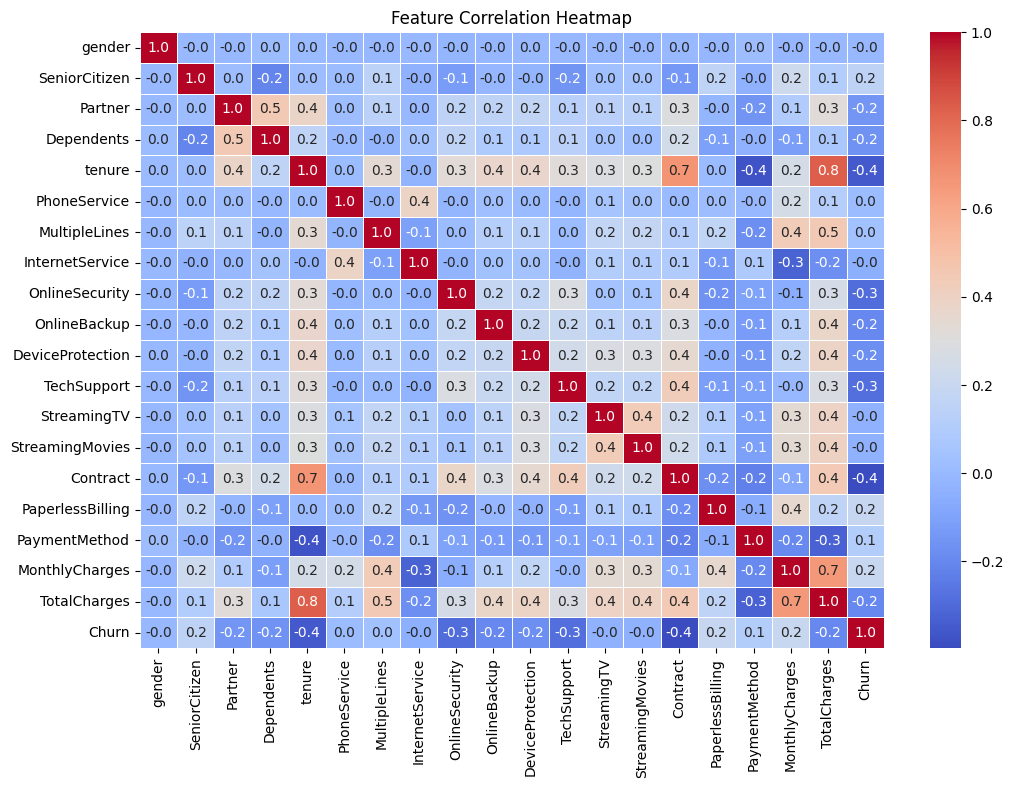

In [9]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [10]:
# Set the correlation threshold
correlation_threshold = 0.80

corr_matrix = df.corr()

# Identify variables with high correlation
high_corr_pairs = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            high_corr_pairs.add((colname1, colname2))

print(f"Highly Correlated Pairs (|correlation| > {correlation_threshold}):")
for pair in high_corr_pairs:
    print(pair)

# Identify columns to drop
columns_to_drop = set()
for col1, col2 in high_corr_pairs:
    # Example strategy: Drop the second column in the pair
    columns_to_drop.add(col2)

# Drop highly correlated columns
df_reduced = df.drop(columns=columns_to_drop)

print(f"Columns dropped: {columns_to_drop}")
print(f"Remaining columns: {list(df_reduced.columns)}")

Highly Correlated Pairs (|correlation| > 0.8):
('TotalCharges', 'tenure')
Columns dropped: {'tenure'}
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


<ipython-input-19-002f41ccb433>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='coolwarm')


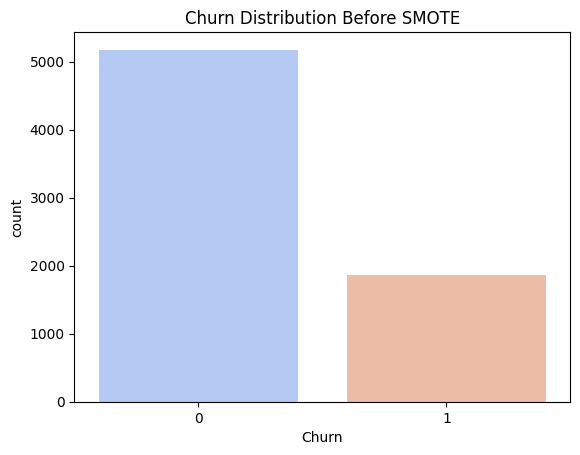

<ipython-input-19-002f41ccb433>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='coolwarm')


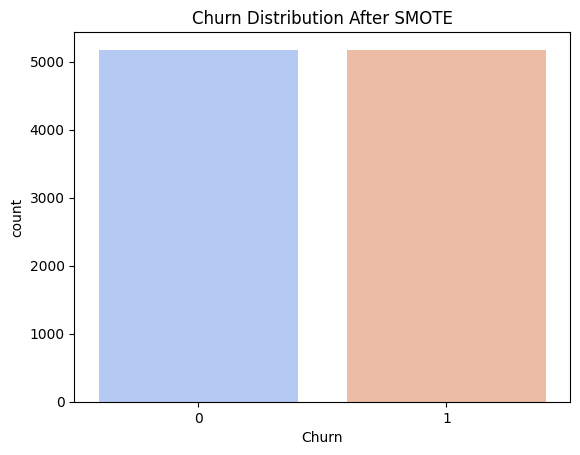

In [19]:
# Train-test split
X = df.drop(columns=['Churn'])
y = df['Churn']

# Solve imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


# Display class distribution before SMOTE
sns.countplot(x=y, palette='coolwarm')
plt.title("Churn Distribution Before SMOTE")
plt.show()

# Display class distribution after SMOTE
sns.countplot(x=y_resampled, palette='coolwarm')
plt.title("Churn Distribution After SMOTE")
plt.show()

In [12]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DS": DecisionTreeClassifier(random_state=42)
}


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1021
           1       0.79      0.84      0.81      1049

    accuracy                           0.81      2070
   macro avg       0.81      0.81      0.81      2070
weighted avg       0.81      0.81      0.81      2070



<Figure size 800x600 with 0 Axes>

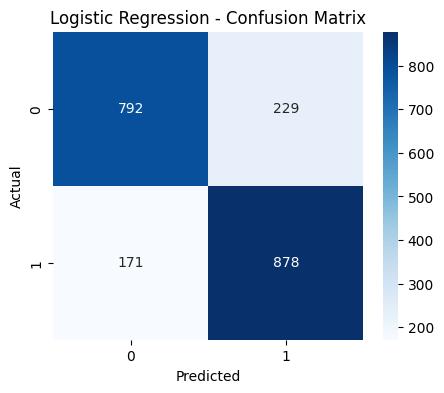

Random Forest Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1021
           1       0.87      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



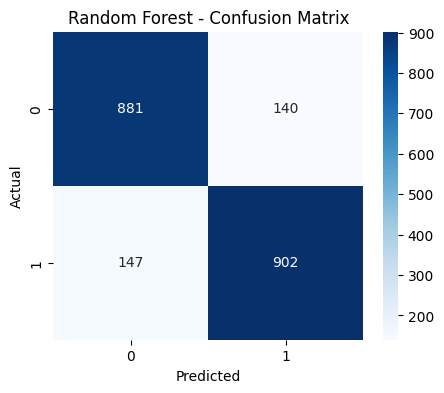

DS Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1021
           1       0.79      0.82      0.80      1049

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070



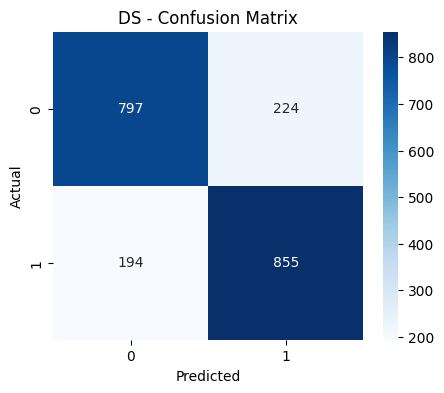

In [13]:
# Train and evaluate models
plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")
    print(classification_report(y_test, y_pred))


    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



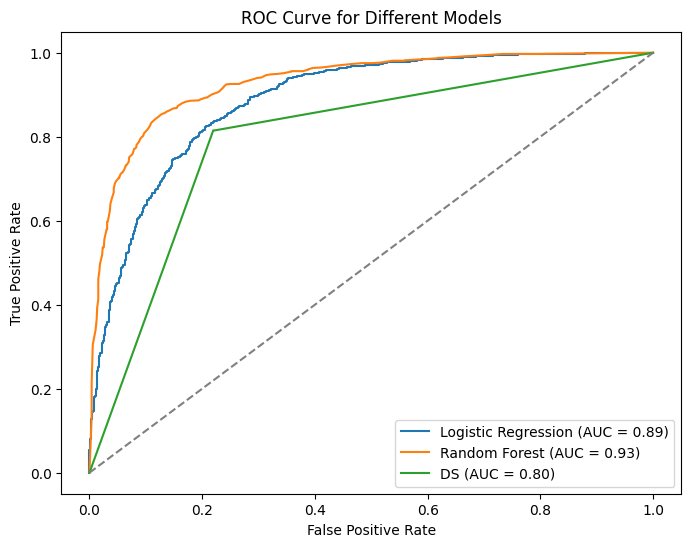

In [15]:
# ROC Curve (Combined)
plt.figure(figsize=(8, 6))  # Create a figure for the combined ROC curve
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Different Models")
plt.legend()
plt.show()

<ipython-input-16-41deb2ee763b>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette="coolwarm")


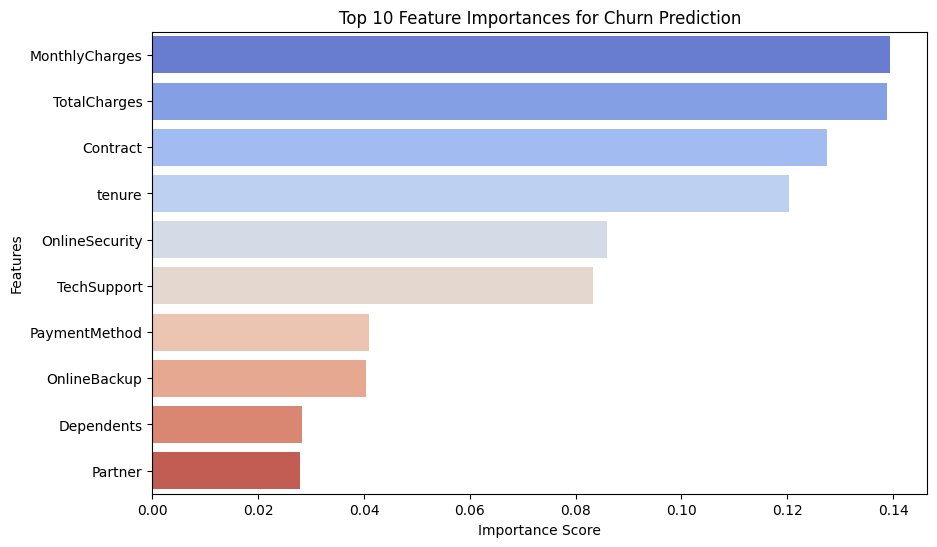

In [16]:
# Feature Importance from Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette="coolwarm")
plt.title("Top 10 Feature Importances for Churn Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()